In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv("Algerian_Forest_Fires_Cleaned.csv")

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [5]:
##drop month,day and yyear
df.drop(['day','month','year'],axis=1,inplace=True)

In [6]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [7]:
df.columns = df.columns.str.strip()

In [8]:
df['Classes'].value_counts()

Classes
fire        137
not fire    105
Name: count, dtype: int64

In [9]:
## Encoding
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [10]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
237,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
238,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
239,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
240,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
241,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [11]:
df['Classes'].value_counts()

Classes
1    137
0    105
Name: count, dtype: int64

In [12]:
## Independent And dependent features
X=df.drop('FWI',axis=1)
y=df['FWI'] # fire weather index

In [13]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [14]:
y


0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
237    6.5
238    0.0
239    0.2
240    0.7
241    0.5
Name: FWI, Length: 242, dtype: float64

In [15]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [16]:
X_train.shape,X_test.shape

((181, 11), (61, 11))

In [17]:
## Feature Selection based on correlaltion
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.648212,-0.303807,-0.328012,0.699516,0.490906,0.374342,0.614434,0.462991,0.521793,0.261365
RH,-0.648212,1.000000,0.265904,0.232014,-0.631167,-0.411804,-0.243917,-0.692522,-0.361926,-0.432743,-0.382479
Ws,-0.303807,0.265904,1.000000,0.221087,-0.168294,0.004003,0.108084,0.008949,0.042299,-0.055013,-0.215537
Rain,-0.328012,0.232014,0.221087,1.000000,-0.543331,-0.283787,-0.297611,-0.343630,-0.294915,-0.382988,-0.084998
FFMC,0.699516,-0.631167,-0.168294,-0.543331,1.000000,0.621366,0.537983,0.752087,0.610946,0.781622,0.259666
DMC,0.490906,-0.411804,0.004003,-0.283787,0.621366,1.000000,0.876718,0.693251,0.983695,0.613444,0.218106
DC,0.374342,-0.243917,0.108084,-0.297611,0.537983,0.876718,1.000000,0.548834,0.946986,0.546385,-0.062488
ISI,0.614434,-0.692522,0.008949,-0.343630,0.752087,0.693251,0.548834,1.000000,0.659442,0.749594,0.288243
BUI,0.462991,-0.361926,0.042299,-0.294915,0.610946,0.983695,0.946986,0.659442,1.000000,0.609670,0.117752
Classes,0.521793,-0.432743,-0.055013,-0.382988,0.781622,0.613444,0.546385,0.749594,0.609670,1.000000,0.185716


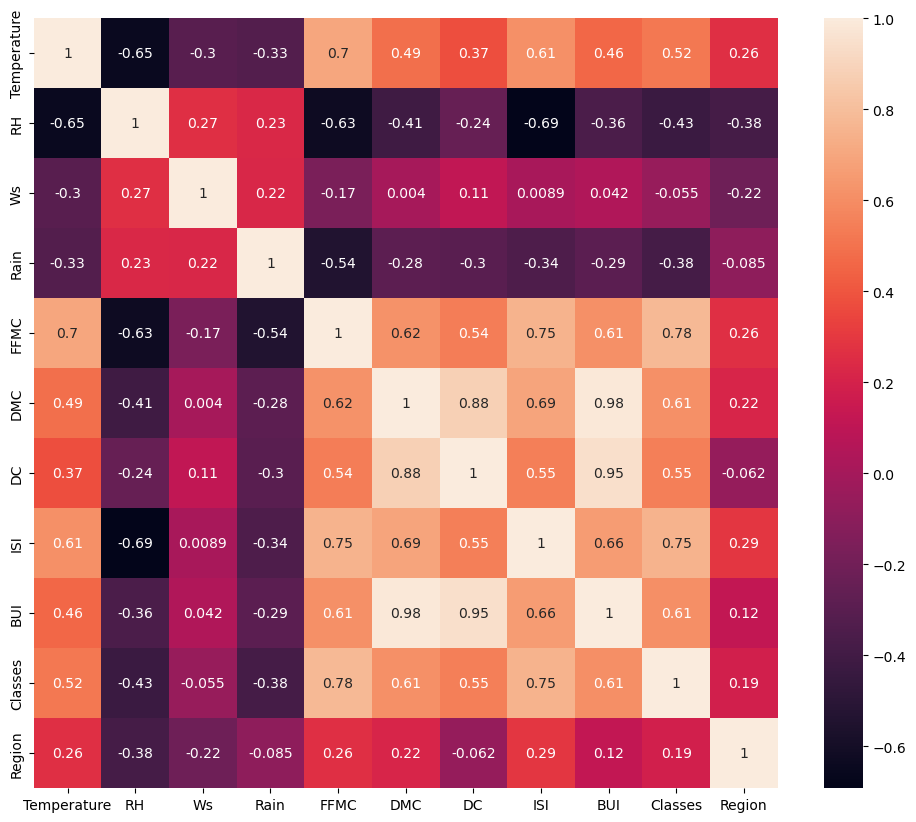

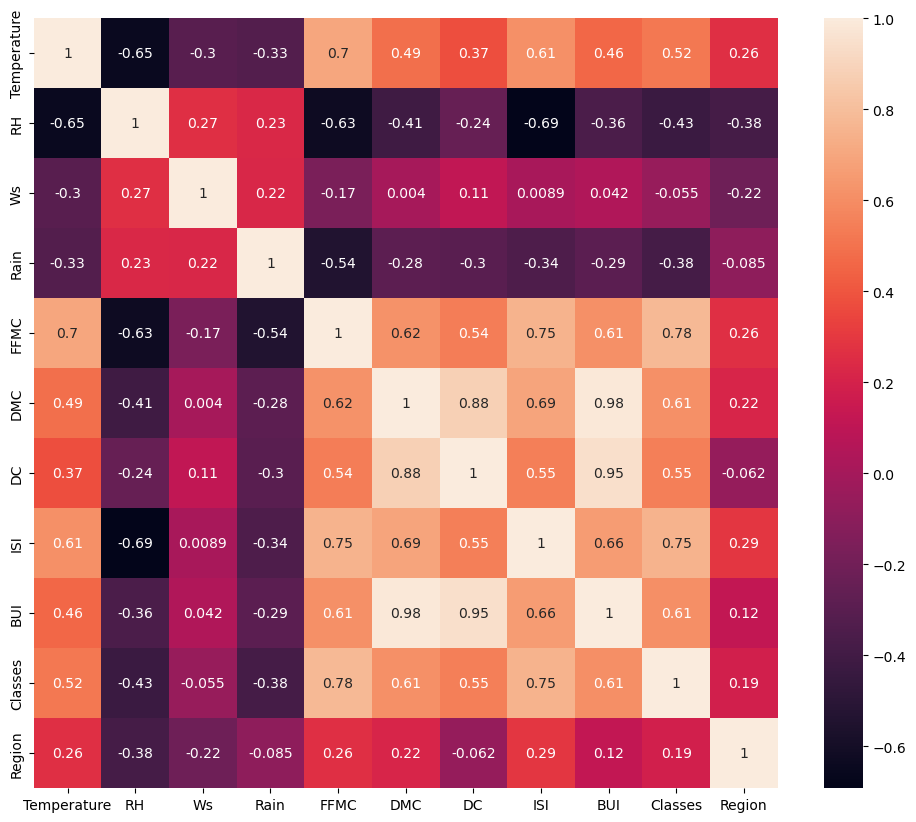

In [19]:
# Check for multicollinearity
plt.figure(figsize=(12,10))
corr=X_train.corr()
sns.heatmap(corr,annot=True)
plt.show()

In [20]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.648212,-0.303807,-0.328012,0.699516,0.490906,0.374342,0.614434,0.462991,0.521793,0.261365
RH,-0.648212,1.000000,0.265904,0.232014,-0.631167,-0.411804,-0.243917,-0.692522,-0.361926,-0.432743,-0.382479
Ws,-0.303807,0.265904,1.000000,0.221087,-0.168294,0.004003,0.108084,0.008949,0.042299,-0.055013,-0.215537
Rain,-0.328012,0.232014,0.221087,1.000000,-0.543331,-0.283787,-0.297611,-0.343630,-0.294915,-0.382988,-0.084998
FFMC,0.699516,-0.631167,-0.168294,-0.543331,1.000000,0.621366,0.537983,0.752087,0.610946,0.781622,0.259666
DMC,0.490906,-0.411804,0.004003,-0.283787,0.621366,1.000000,0.876718,0.693251,0.983695,0.613444,0.218106
DC,0.374342,-0.243917,0.108084,-0.297611,0.537983,0.876718,1.000000,0.548834,0.946986,0.546385,-0.062488
ISI,0.614434,-0.692522,0.008949,-0.343630,0.752087,0.693251,0.548834,1.000000,0.659442,0.749594,0.288243
BUI,0.462991,-0.361926,0.042299,-0.294915,0.610946,0.983695,0.946986,0.659442,1.000000,0.609670,0.117752
Classes,0.521793,-0.432743,-0.055013,-0.382988,0.781622,0.613444,0.546385,0.749594,0.609670,1.000000,0.185716


In [ ]:
# Multicollinearity
# Yes. If two independent variables are highly correlated and provide almost the same information,
# we can remove one of them to reduce multicollinearity and make the linear regression model more stable.

In [21]:
def correlation(dataset, threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:  # absolute covers the - values also
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [22]:
## threshold -- Domain expertise
corr_features=correlation(X_train,0.85)

In [23]:
corr_features

{'BUI', 'DC'}

In [24]:
## drop features when correlation is more than 0.85
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape,X_test.shape

((181, 9), (61, 9))

## featrue scaling or standardization

In [25]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [26]:
X_train_scaled

array([[-0.8343795 ,  0.75856688,  1.27359309, ..., -0.6072176 ,
        -1.07459849, -0.96204569],
       [-0.03248911, -0.5214682 , -0.51616117, ...,  0.08088369,
         0.93058013,  1.03945167],
       [-0.8343795 , -1.46465194, -2.66386629, ..., -0.46485181,
         0.93058013,  1.03945167],
       ...,
       [-1.90356667,  0.89330741,  0.55769138, ..., -1.05804258,
        -1.07459849, -0.96204569],
       [ 1.03669806, -0.45409793,  0.19974053, ...,  0.84016787,
         0.93058013,  1.03945167],
       [-0.5670827 ,  0.96067768,  1.9894948 , ..., -0.84449391,
        -1.07459849, -0.96204569]])

# Box Plots to understand effect of standard scaler

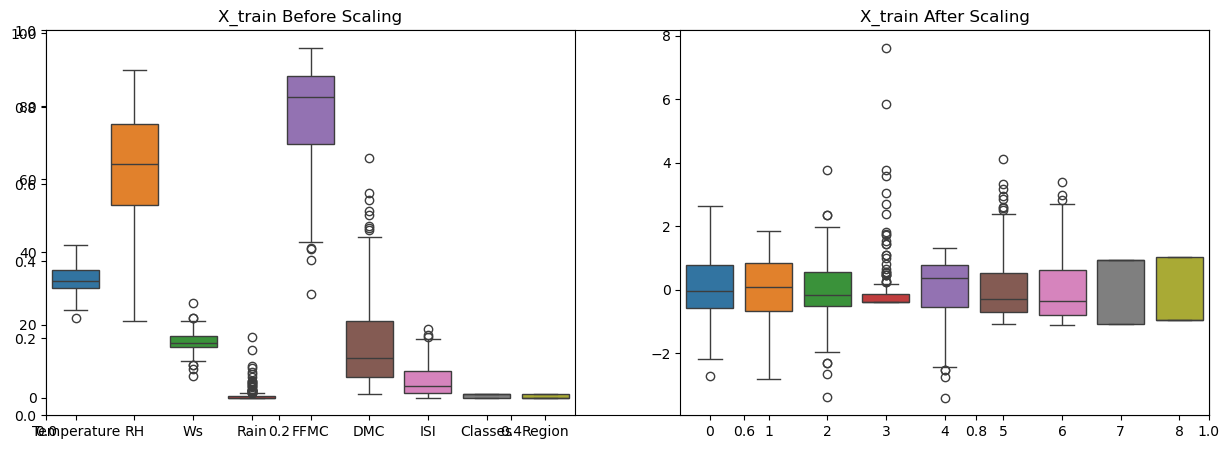

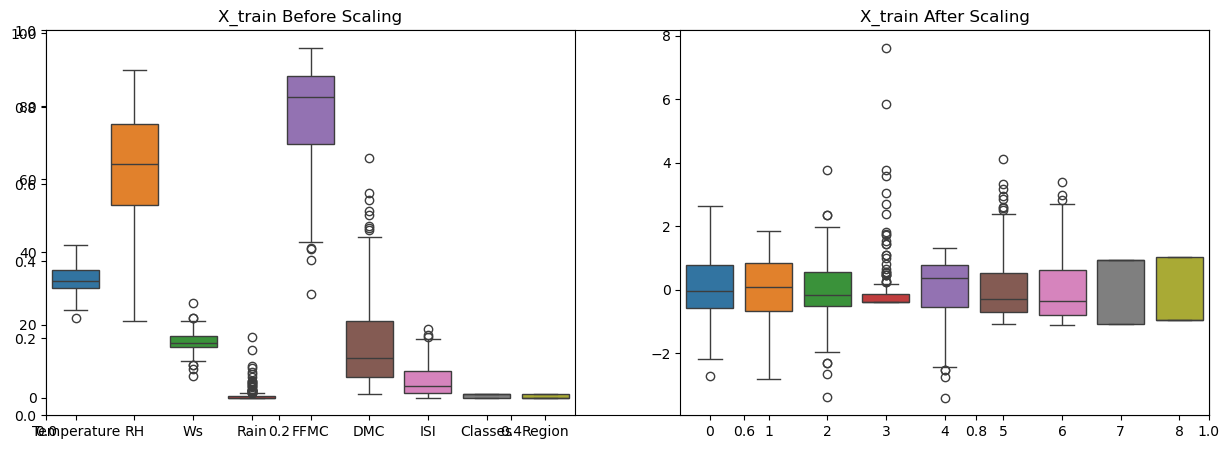

In [28]:
plt.subplots(figsize=(15,5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')
plt.show()

# Linear Regression

Mean absolute error 0.5886251489225811
R2 score 0.9835542010762964


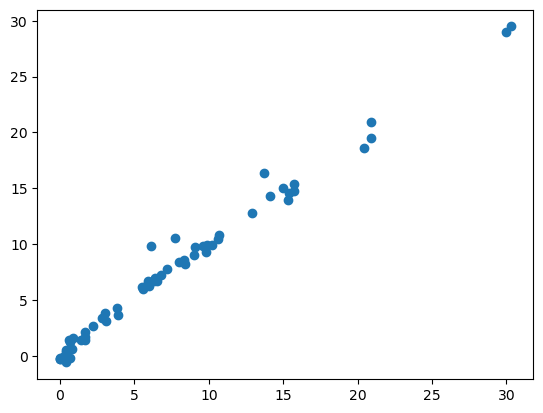

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train) ## train the model
y_pred=linreg.predict(X_test_scaled) ## test
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 score", score)
plt.scatter(y_test,y_pred)
plt.show()

# Lasso Regression

Mean absolute error 1.1447666960881513
R2_score 0.9498481990583274


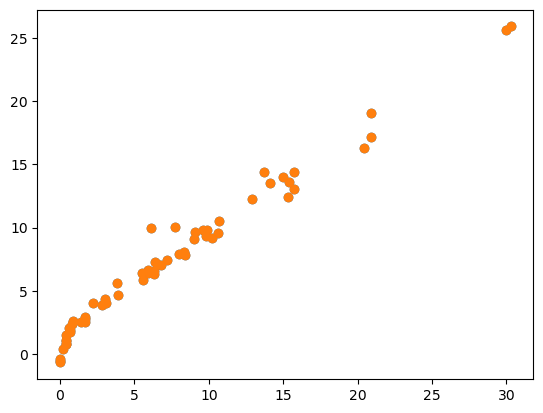

In [31]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2_score", score)
plt.scatter(y_test,y_pred)
plt.show()

## cross Validation Lasso

In [33]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)

LassoCV(cv=5)

In [37]:

y_pred=lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 0.682492182863652
R2 Score 0.9805353752841544


## Ridge Regression model

Mean absolute error 0.617404139288942
r2_score 0.9827313546901432


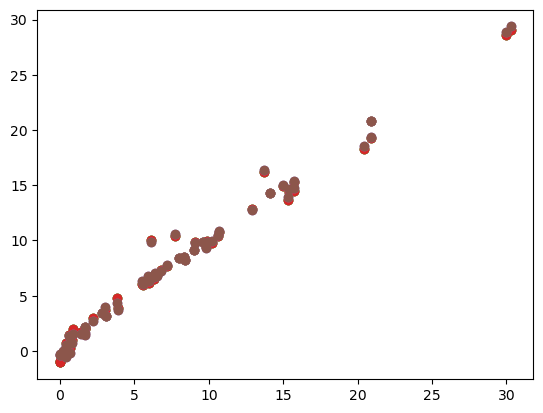

In [39]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("r2_score", score)
plt.scatter(y_test,y_pred)
plt.show()

Mean absolute error 0.8574916655748662
r2 Score 0.9730879950256979


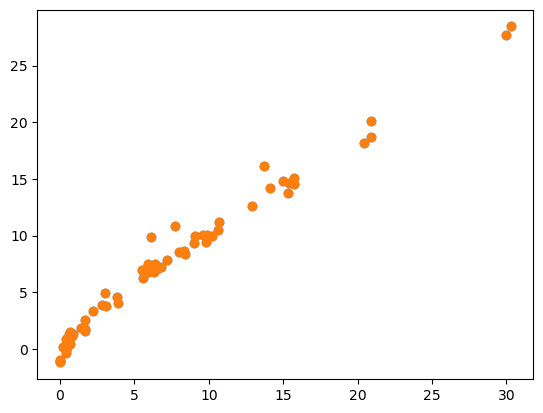

In [41]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred=ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("r2 Score", score)
plt.show()

In [42]:
# get_params() is a method used to display all the parameters (configuration settings) of a RidgeCV model. 
# It shows values such as alphas, cv, fit_intercept, and other options used by the model. It does not train the model or make predictions.
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': None,
 'store_cv_values': 'deprecated'}

Mean absolute error 1.8909524872180887
R2 Score 0.8732834178137032


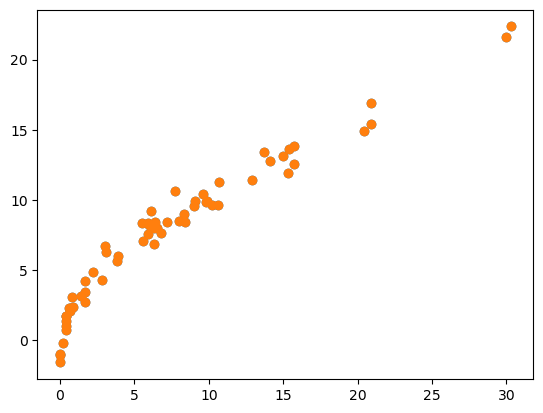

In [44]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)
plt.show()

In [45]:
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(X_train_scaled,y_train)
y_pred=elasticcv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 0.7434923108474782
R2 Score 0.978556189535055


In [47]:
elasticcv.alphas_

array([13.89798097, 12.96130356, 12.08775508, 11.27308085, 10.51331293,
        9.80475082,  9.14394343,  8.52767225,  7.95293568,  7.41693443,
        6.91705788,  6.45087133,  6.01610419,  5.6106389 ,  5.23250062,
        4.87984759,  4.55096219,  4.24424257,  3.95819483,  3.69142575,
        3.442636  ,  3.21061386,  2.99422923,  2.7924282 ,  2.60422789,
        2.42871164,  2.26502461,  2.11236953,  1.97000289,  1.83723129,
        1.71340805,  1.59793008,  1.49023494,  1.3897981 ,  1.29613036,
        1.20877551,  1.12730808,  1.05133129,  0.98047508,  0.91439434,
        0.85276722,  0.79529357,  0.74169344,  0.69170579,  0.64508713,
        0.60161042,  0.56106389,  0.52325006,  0.48798476,  0.45509622,
        0.42442426,  0.39581948,  0.36914257,  0.3442636 ,  0.32106139,
        0.29942292,  0.27924282,  0.26042279,  0.24287116,  0.22650246,
        0.21123695,  0.19700029,  0.18372313,  0.17134081,  0.15979301,
        0.14902349,  0.13897981,  0.12961304,  0.12087755,  0.11

# pickle the machine learning models, preprocessing model standardscaler


In [54]:
import pickle 
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(scaler,open('ridge.pkl','wb'))

In [49]:
scaler

StandardScaler()

In [52]:
#we can taking the ridge because it is perfect r square
ridge

Ridge()